In [95]:
import kagglehub
path = kagglehub.dataset_download("piyshsss/finacne")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/piyshsss/finacne


In [96]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    GlobalAveragePooling2D
)
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam,SGD
from tensorflow.keras import layers


In [97]:
CLASS_IMG_DIR = "/kaggle/input/datasets/piyshsss/finacne/Classification/Classification/JPEGImages"
CLASS_SPLIT_DIR = "/kaggle/input/datasets/piyshsss/finacne/Classification/Classification/Spilt"
ANNOTATION_DIR = "/kaggle/input/datasets/piyshsss/finacne/Detection/Detection/Annotations"


In [98]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 120
NUM_CLASSES = 4

In [99]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

In [100]:
def create_dataset(split_file):
    X=[]
    y_grade=[]
    y_count=[]
    severity_map={
        "levle0":0,
        "levle1":1,
        "levle2":2,
        "levle3":3
    }
    class_names={
        0:"Mild",
        1:"Moderate",
        2:"Severe",
        3:"Very Severe"
    }
    with open(split_file,"r") as f:
        lines=f.readlines()
    for line in lines:
        line=line.strip()
        parts=line.split()
        img_name=parts[0]
        img_name=img_name.replace(".jpg.jpg",".jpg")
        if len(parts)>=3:
            lesion_count=int(parts[2])
        else:
            lesion_count=0
        img_path=os.path.join(CLASS_IMG_DIR,img_name)
        if not os.path.exists(img_path):
            print("Missing Image:",img_path)
            continue
        severity=None
        for key in severity_map:
            if img_name.startswith(key):
                severity=severity_map[key]
                break
        if severity is None:
            continue
        img=cv2.imread(img_path)
        if img is None:
            print("Could not read:",img_path)
            continue
        img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
        img=cv2.resize(
            img,
            (IMG_SIZE,IMG_SIZE)
        )
        img=img/255.0
        X.append(img)
        y_grade.append(severity)
        y_count.append(lesion_count)
    print("Loaded Images:",len(X))
    return(
        np.array(X),
        np.array(y_grade),
        np.array(y_count)
    )

In [101]:
for fold in range(5):
    train_file=os.path.join(
        CLASS_SPLIT_DIR,
        f"NNEW_trainval_{fold}.txt"
    )
    test_file=os.path.join(
        CLASS_SPLIT_DIR,
        f"NNEW_test_{fold}.txt"
    )
   

In [102]:
X_train, y_train_grade, y_train_count = create_dataset(train_file)
X_test, y_test_grade, y_test_count = create_dataset(test_file)
(
    X_train,
    X_val,
    y_train_grade,
    y_val_grade,
    y_train_count,
    y_val_count
) = train_test_split(
    X_train,
    y_train_grade,
    y_train_count,
    test_size=0.2,
    random_state=42,
    stratify=y_train_grade
)

Loaded Images: 1165
Loaded Images: 292


In [103]:
class_weights_array = compute_class_weight(

    class_weight='balanced',

    classes=np.unique(y_train_grade),

    y=y_train_grade
)

class_weights = {

    0:class_weights_array[0],

    1:class_weights_array[1],

    2:class_weights_array[2] * 1.5,

    3:class_weights_array[3] * 1.3
}

print(class_weights)

{0: np.float64(0.7327044025157232), 1: np.float64(0.571078431372549), 2: np.float64(2.936974789915966), 3: np.float64(3.481609195402299)}


In [104]:
inputs = Input(
    shape=(IMG_SIZE, IMG_SIZE, 3)
)
augmented = data_augmentation(inputs)

In [105]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_tensor=augmented
)

In [106]:
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(
    256,
    activation='relu'
)(x)
x = Dropout(0.5)(x)

In [107]:
grading_output = Dense(
    NUM_CLASSES,
    activation='softmax',
    name='grading_output'

)(x)

In [108]:
count_output = Dense(
    1,
    activation='linear',
    name='count_output'
)(x)

In [109]:
model = Model(
    inputs=inputs,
    outputs=[
        grading_output,
        count_output
   ]
)

In [110]:
model.compile(
    optimizer=SGD(
        learning_rate=0.001
    ),
    loss={
        'grading_output':'SparseCategoricalCrossentropy',
        'count_output':'mse'
    },
    metrics={
        'grading_output':['accuracy'],
        'count_output':['mae']
    },
    loss_weights={
        'grading_output':1.0,
        'count_output':0.001
    }
)

In [111]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_grading_output_accuracy',
    patience=6,
    restore_best_weights=True
)



In [112]:
ModelCheckpoint(
    'best_model.h5',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

In [113]:
callbacks=[early_stop, checkpoint]

In [114]:
history = model.fit(
    X_train,
    {
        'grading_output':
        y_train_grade,
        'count_output':
        y_train_count
    },
    validation_data=(
        X_val,
        {
            'grading_output':
            y_val_grade,
           'count_output':
            y_val_count
      }
    ),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    verbose=1
)

Epoch 1/120
30/30 ━━━━━━━━━━━━━━━━━━━━ 27s 410ms/step - count_output_loss: 419.7074 - count_output_mae: 13.3626 - grading_output_accuracy: 0.3219 - grading_output_loss: 1.5018 - loss: 1.9512 - val_count_output_loss: 466.2242 - val_count_output_mae: 14.4051 - val_grading_output_accuracy: 0.0901 - val_grading_output_loss: 1.5240 - val_loss: 1.9821
Epoch 2/120
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 307ms/step - count_output_loss: 455.4863 - count_output_mae: 13.0354 - grading_output_accuracy: 0.4227 - grading_output_loss: 1.3129 - loss: 1.7379 - val_count_output_loss: 467.1270 - val_count_output_mae: 14.4337 - val_grading_output_accuracy: 0.0901 - val_grading_output_loss: 1.5491 - val_loss: 2.0075
Epoch 3/120
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 308ms/step - count_output_loss: 410.8127 - count_output_mae: 12.8103 - grading_output_accuracy: 0.4045 - grading_output_loss: 1.2517 - loss: 1.6827 - val_count_output_loss: 462.8015 - val_count_output_mae: 14.2827 - val_grading_output_accuracy: 0.0901 - val_gradi

In [115]:
model.save("acne2812022.h5")

In [116]:
pred_grade, pred_count = model.predict(X_test)
y_pred = np.argmax(
    pred_grade,
    axis=1
)

10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 245ms/step


In [117]:
accuracy = accuracy_score(
    y_test_grade,
    y_pred
)
precision = precision_score(
    y_test_grade,
    y_pred,
    average='weighted',
    zero_division=0
)
recall = recall_score(
    y_test_grade,
    y_pred,
    average='weighted',
    zero_division=0
)
f1 = f1_score(
    y_test_grade,
    y_pred,
    average='weighted',
    zero_division=0
)
y_test_bin = label_binarize(
    y_test_grade,
    classes=[0,1,2,3]
)
auc = roc_auc_score(
    y_test_bin,
    pred_grade,
    multi_class='ovr'
)
print("\nAccuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("AUC      :", auc)


Accuracy : 0.75
Precision: 0.7514814481388431
Recall   : 0.75
F1 Score : 0.7410592123790711
AUC      : 0.9105067915867592



Confusion Matrix

[[ 81  18   0   0]
 [ 17 109   1   0]
 [  0  20  15   2]
 [  0   4  11  14]]

Classification Report

              precision    recall  f1-score   support

        Mild       0.83      0.82      0.82        99
    Moderate       0.72      0.86      0.78       127
      Severe       0.56      0.41      0.47        37
 Very Severe       0.88      0.48      0.62        29

    accuracy                           0.75       292
   macro avg       0.74      0.64      0.67       292
weighted avg       0.75      0.75      0.74       292



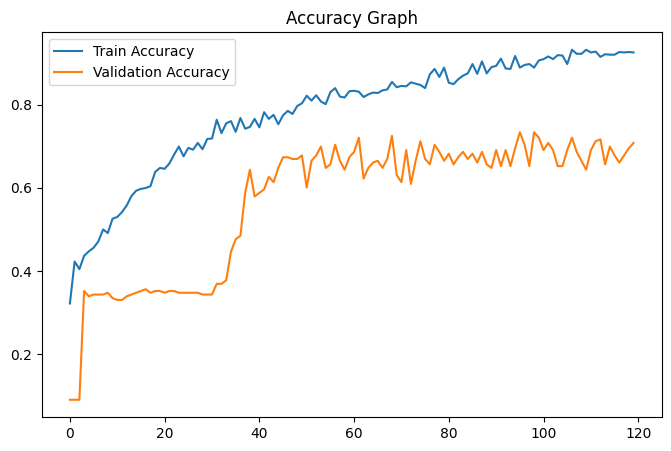

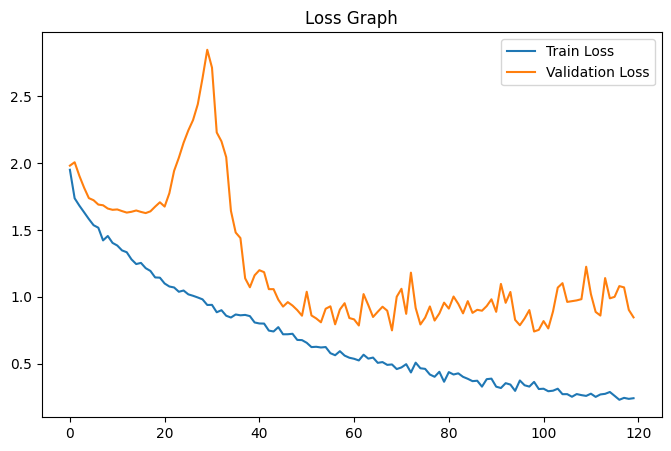

In [118]:
cm = confusion_matrix(
    y_test_grade,
    y_pred
)
print("\nConfusion Matrix\n")
print(cm)
print("\nClassification Report\n")
print(
    classification_report(
        y_test_grade,
        y_pred,
        target_names=[
            "Mild",
            "Moderate",
            "Severe",
            "Very Severe"
        ],
        zero_division=0
    )
)
plt.figure(figsize=(8,5))
plt.plot(
    history.history['grading_output_accuracy'],
    label='Train Accuracy'
)
plt.plot(
    history.history['val_grading_output_accuracy'],
    label='Validation Accuracy'
)
plt.title("Accuracy Graph")
plt.legend()
plt.show()
plt.figure(figsize=(8,5))
plt.plot(
    history.history['loss'],
   label='Train Loss'
)
plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)
plt.title("Loss Graph")
plt.legend()
plt.show()